---
## VER Human+Object Preparation Pipeline (Dual-Class)

The following cells prepare a combined dataset of **human** and **object** signals for downstream ML models.

### Step 1 – Import Libraries

Import all libraries needed to load, combine, and prepare the dual-class dataset.

In [94]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

# Import TensorFlow/Keras lazily so the notebook still works if TF is not installed elsewhere
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Optional engine for reading .xlsx header schema (if needed)
try:
    import openpyxl  # noqa: F401
except ImportError:
    openpyxl = None

# Directory for saving result figures
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

print("Libraries for VER dual-class pipeline imported.")

Libraries for VER dual-class pipeline imported.


### Step 2 – Load Datasets (Human & Object)

Load the separate human and object CSV files referenced in the project into individual DataFrames.

In [95]:
# Paths to the original human and object datasets (relative to project root)
human_path = "Human_1500.csv"
object_path = "Objects_1500.csv"

human_df = pd.read_csv(human_path, header=None)
object_df = pd.read_csv(object_path, header=None)

print("Human dataset shape:", human_df.shape)
print("Object dataset shape:", object_df.shape)

Human dataset shape: (1500, 16384)
Object dataset shape: (1500, 16384)


### Step 3 – Combine Datasets in Memory

Concatenate the human and object DataFrames into a single combined DataFrame **without writing anything to disk**.

In [96]:
combined_df = pd.concat([human_df, object_df], ignore_index=True)

print("Combined DataFrame shape:", combined_df.shape)
print("Number of human rows:", len(human_df))
print("Number of object rows:", len(object_df))

Combined DataFrame shape: (3000, 16384)
Number of human rows: 1500
Number of object rows: 1500


### Step 4 – Apply Header Structure

Load the header schema from `Project_Docs/Header structure Winter 2021 (1).xlsx` and apply those column names/structure to the combined DataFrame (in memory only).

In [97]:
header_path = "/content/Header structure Winter 2021 (1).xlsx" # Updated path

# Load header schema (assume first row contains the desired column names)
header_schema = pd.read_excel(header_path, header=None)
header_columns = header_schema.iloc[0].tolist()

# Apply header names ONLY to the first N columns,
# keeping all remaining columns and data in combined_df unchanged
n_header_cols = len(header_columns)

# We can only apply as many headers as there are columns in combined_df
n_apply = min(n_header_cols, combined_df.shape[1])

current_cols = list(combined_df.columns)
for i in range(n_apply):
    current_cols[i] = header_columns[i]
combined_df.columns = current_cols

print(f"Header schema columns: {n_header_cols}")
print(f"Applied header names to first {n_apply} columns. Total columns in combined_df remain: {combined_df.shape[1]}")

Header schema columns: 17
Applied header names to first 17 columns. Total columns in combined_df remain: 16384


### Step 5 – Update Column 3 for Dual Classes

Modify **column 3** so it encodes the two classes (human vs. object) for each row in the combined DataFrame.

In [98]:
# Ensure there are at least 3 columns to hold the class labels
if combined_df.shape[1] < 3:
    raise ValueError("Combined DataFrame has fewer than 3 columns; cannot set class labels in column 3.")

n_human = len(human_df)
n_object = len(object_df)

# Use position-based indexing: third column (index 2) holds the dual-class label (0/1 for ML models)
# Convention: 0 = object, 1 = human
combined_df.iloc[:n_human, 2] = 1  # human
combined_df.iloc[n_human:n_human + n_object, 2] = 0  # object

print("Column 3 updated with numeric labels: 1=human, 0=object.")
print(combined_df.shape)

Column 3 updated with numeric labels: 1=human, 0=object.
(3000, 16384)


### Step 6 – Preview Data for Modeling

Display the first 10 rows and first 20 columns of the final combined DataFrame to verify it is ready for ML models.

In [99]:
# Show first 10 rows and first 20 columns of the prepared dataset
combined_df.iloc[:10, :20]

,header length (number of table elements),data length,class detected,measurement type\nFFT / ADC,dependent on table element D either frequency resolution Δf or sampling time Δt,currently irrelevant,sampling frequency f_s (Hz),ADC resolution (bits),currently irrelevant,currently irrelevant,\ndistance between sensor and first object (round-trip-time in µs),FFT Window length,currently irrelevant,software version (RP),aux 1,aux 2,data …..,17,18,19
0,68,50000,1,1,512,1,1953125,14,15,2622,0.000000,0,0,2,1,0,260611.3750,-35,-31,-26
1,68,50000,1,1,512,1,1953125,14,15,2622,0.000000,0,0,2,1,0,260672.2500,-120,-133,-142
2,68,50000,1,1,512,1,1953125,14,15,2622,0.000000,0,0,2,1,0,260734.6406,-46,-47,-47
3,68,50000,1,1,512,1,1953125,14,15,2622,2.265292,0,0,2,1,0,260794.2500,111,101,67
4,68,50000,1,1,512,1,1953125,14,15,2622,0.000000,0,0,2,1,0,260860.0000,-99,-101,-102
5,68,50000,1,1,512,1,1953125,14,15,2622,0.000000,0,0,2,1,0,260926.7969,-18,-10,-7
6,68,50000,1,1,512,1,1953125,14,15,2622,0.000000,0,0,2,1,0,261006.3594,-118,-112,-111
7,68,50000,1,1,512,1,1953125,14,15,2622,0.159760,0,0,2,1,0,261068.3906,-79,-78,-75
8,68,50000,1,1,512,1,1953125,14,15,2622,0.000000,0,0,2,1,0,261147.5938,-20,-22,-29
9,68,50000,1,1,512,1,1953125,14,15,2622,0.000000,0,0,2,1,0,261221.0625,-26,-24,-21


### Step 7 – Drop Irrelevant Columns

From the combined DataFrame, drop columns with original positional indices **0**, **1**, and **3–17** (inclusive). The remaining columns will be used for modeling (label + features).

In [100]:
# Drop columns by original positional indices: 0, 1, and 3–17 (inclusive)
cols_to_drop_pos = [0, 1] + list(range(3, 18))

# Guard against cases where the DataFrame has fewer columns than the largest index
max_idx = combined_df.shape[1] - 1
cols_to_drop_pos = [idx for idx in cols_to_drop_pos if idx <= max_idx]

cols_to_drop = combined_df.columns[cols_to_drop_pos]

df_model = combined_df.drop(columns=cols_to_drop).copy()

print("Original combined_df shape:", combined_df.shape)
print("Columns dropped (by name):", list(cols_to_drop))
print("Modeling DataFrame shape (df_model):", df_model.shape)

Original combined_df shape: (3000, 16384)
Columns dropped (by name): ['header length (number of table elements)', 'data length', 'measurement type\nFFT / ADC', 'dependent on table element D either frequency resolution Δf  or sampling time Δt', 'currently irrelevant', 'sampling frequency f_s (Hz)', 'ADC resolution (bits) ', 'currently irrelevant', 'currently irrelevant', '\ndistance between sensor and first object (round-trip-time in µs)', 'FFT Window length', 'currently irrelevant', 'software version (RP)', 'aux 1', 'aux 2', 'data …..', 17]
Modeling DataFrame shape (df_model): (3000, 16367)


### Step 8 – Prepare Features (X) and Labels (y)

Use **column 3 (index 2)** as the dual-class label (0 = object, 1 = human) and all remaining columns in `df_model` as features.

In [101]:
# Column index for the dual-class label (from previous step)
label_col_idx = 0  # 0 = object, 1 = human (Corrected to 0 for df_model)

# Extract labels as a 1D numpy array of ints
y = df_model.iloc[:, label_col_idx].astype(int).values

# Features are all remaining columns in df_model except the label column
X = df_model.drop(df_model.columns[label_col_idx], axis=1).values.astype(np.float32)

print("Feature matrix X shape:", X.shape)
print("Label vector y shape:", y.shape)
print("Class distribution (value counts):")
print(pd.Series(y).value_counts())

Feature matrix X shape: (3000, 16366)
Label vector y shape: (3000,)
Class distribution (value counts):
1    1500
0    1500
Name: count, dtype: int64


### Concise Digital Signal Visualization

Here's a quick look at how a representative human signal differs from an object signal directly from the preprocessed data.

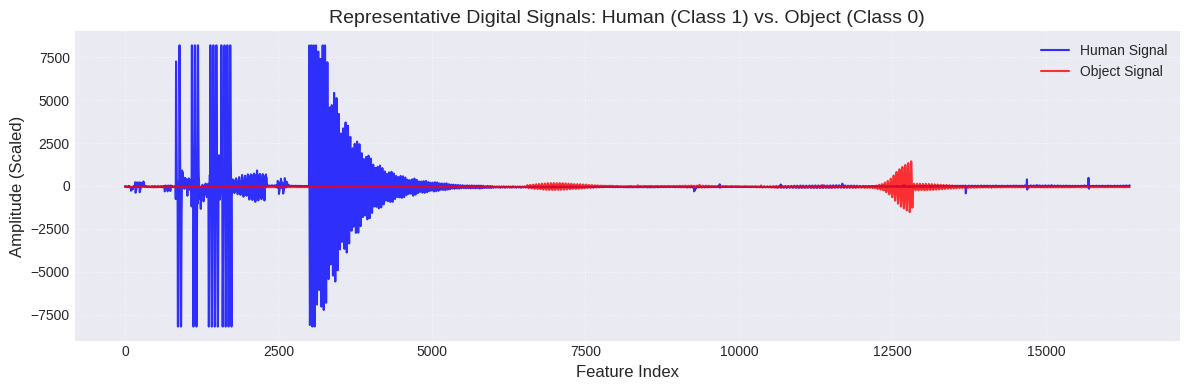

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

# Plot a single representative human and object signal
plt.figure(figsize=(12, 4))
# Assuming the actual signal data starts from column index 1 (after dropping label and previous features)
# and combined_df was used to create X (features without label)
plt.plot(X[y == 1][0], label='Human Signal', color='blue', alpha=0.8)
plt.plot(X[y == 0][0], label='Object Signal', color='red', alpha=0.8)
plt.title('Representative Digital Signals: Human (Class 1) vs. Object (Class 0)', fontsize=14)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Amplitude (Scaled)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Step 9 – Train/Test Split and Scaling

Split the data into **80% train / 20% test** with a fixed random state and standardize the features.

In [103]:


# Decide whether we can safely use stratification
class_counts = pd.Series(y).value_counts()
min_class_count = class_counts.min()

if min_class_count < 2:
    print(
        "Warning: At least one class has fewer than 2 samples. "
        "Proceeding without stratification in train_test_split."
    )
    stratify_arg = None
else:
    stratify_arg = y

# 80/20 train-test split with fixed random_state
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_arg,
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Class counts in y:")
print(class_counts)
print("\nX_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Dictionaries to collect model metrics for final comparison
model_accuracies = {}
model_macro_f1 = {}

Class counts in y:
1    1500
0    1500
Name: count, dtype: int64

X_train shape: (2400, 16366)
X_test shape: (600, 16366)
y_train shape: (2400,)
y_test shape: (600,)


### SVM – Dual-Class Classification

Train an SVM classifier (`sklearn.svm.SVC`) on the scaled training data and evaluate on the test set.

In [104]:
from sklearn.linear_model import SGDClassifier

# Using SGDClassifier with 'hinge' loss to approximate a Linear SVM
# This is generally much faster for high-dimensional datasets.
svm_clf = SGDClassifier(
    loss='hinge',  # Corresponds to a linear SVM
    alpha=0.0001,  # Regularization strength
    max_iter=1000, # Number of passes over the training data
    tol=1e-3,      # Tolerance for stopping criterion
    random_state=42,
    early_stopping=True, # Stop training when validation score doesn't improve
    validation_fraction=0.1, # Fraction of training data to set aside as validation set
    n_iter_no_change=5, # Number of iterations with no improvement to wait before stopping
)

svm_clf.fit(X_train_scaled, y_train)
y_pred_svm = svm_clf.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_macro_f1 = f1_score(y_test, y_pred_svm, average="macro")

print(f"SVM (SGDClassifier) Test accuracy: {svm_accuracy:.4f}")
print("\nSVM (SGDClassifier) Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nSVM (SGDClassifier) Classification Report:\n")
print(classification_report(y_test, y_pred_svm, digits=4))

model_accuracies["SVM"] = svm_accuracy
model_macro_f1["SVM"] = svm_macro_f1

SVM (SGDClassifier) Test accuracy: 0.6733

SVM (SGDClassifier) Confusion Matrix:
[[210  90]
 [106 194]]

SVM (SGDClassifier) Classification Report:

              precision    recall  f1-score   support

           0     0.6646    0.7000    0.6818       300
           1     0.6831    0.6467    0.6644       300

    accuracy                         0.6733       600
   macro avg     0.6738    0.6733    0.6731       600
weighted avg     0.6738    0.6733    0.6731       600



### Random Forest – Dual-Class Classification

Train a `RandomForestClassifier` on the scaled training data and evaluate on the test set.

In [105]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_clf.fit(X_train_scaled, y_train)

y_pred_rf = rf_clf.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_macro_f1 = f1_score(y_test, y_pred_rf, average="macro")

print(f"Random Forest Test accuracy: {rf_accuracy:.4f}")
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf, digits=4))

model_accuracies["Random Forest"] = rf_accuracy
model_macro_f1["Random Forest"] = rf_macro_f1

Random Forest Test accuracy: 0.9483

Random Forest Confusion Matrix:
[[290  10]
 [ 21 279]]

Random Forest Classification Report:

              precision    recall  f1-score   support

           0     0.9325    0.9667    0.9493       300
           1     0.9654    0.9300    0.9474       300

    accuracy                         0.9483       600
   macro avg     0.9489    0.9483    0.9483       600
weighted avg     0.9489    0.9483    0.9483       600



### CNN – Dual-Class Classification (TensorFlow/Keras)

Train a 1D CNN on the scaled feature sequences using `tensorflow.keras` and evaluate on the test set.

In [106]:
# Prepare 3D input tensors for Conv1D: (samples, timesteps/features, channels)
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

cnn_model = keras.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], 1)),
    layers.Conv1D(32, kernel_size=3, activation="relu"),
    layers.Conv1D(64, kernel_size=3, activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),  # binary classification (0/1)
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
y_pred_cnn = (cnn_model.predict(X_test_cnn, verbose=0) > 0.5).astype(int).flatten()
cnn_macro_f1 = f1_score(y_test, y_pred_cnn, average="macro")

print(f"CNN Test accuracy: {cnn_acc:.4f}")
print("\nCNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnn))
print("\nCNN Classification Report:\n")
print(classification_report(y_test, y_pred_cnn, digits=4))

model_accuracies["CNN"] = float(cnn_acc)
model_macro_f1["CNN"] = cnn_macro_f1

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.5135 - loss: 0.6811 - val_accuracy: 0.5833 - val_loss: 0.6534
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.6016 - loss: 0.6511 - val_accuracy: 0.6396 - val_loss: 0.6324
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.6427 - loss: 0.6289 - val_accuracy: 0.6500 - val_loss: 0.6254
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.6599 - loss: 0.6157 - val_accuracy: 0.6646 - val_loss: 0.6111
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.6745 - loss: 0.6046 - val_accuracy: 0.6625 - val_loss: 0.6081
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.6807 - loss: 0.5966 - val_accuracy: 0.6708 - val_loss: 0.5970
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.6943 - loss: 0.5837 - val_accuracy: 0.6667 - val_loss: 0.5929
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.7036 - loss: 0.5759 - val_accuracy: 0.6687 - v

### TCN – Dual-Class Classification (Dilated Causal Conv1D)

Train a simple Temporal Convolutional Network (TCN)-style model using stacked **dilated causal Conv1D** layers in Keras and evaluate on the test set.

In [107]:
# Reuse the same 3D representation of the inputs (tf/keras already imported in CNN cell)
X_train_tcn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_tcn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

inputs = keras.Input(shape=(X_train_tcn.shape[1], 1))
x = inputs

# Stack of dilated causal Conv1D layers (TCN-style)
for dilation_rate in [1, 2, 4, 8]:
    x = layers.Conv1D(
        filters=32,
        kernel_size=3,
        padding="causal",
        activation="relu",
        dilation_rate=dilation_rate,
    )(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

tcn_model = keras.Model(inputs=inputs, outputs=outputs)

tcn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_tcn = tcn_model.fit(
    X_train_tcn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

tcn_loss, tcn_acc = tcn_model.evaluate(X_test_tcn, y_test, verbose=0)
y_pred_tcn = (tcn_model.predict(X_test_tcn, verbose=0) > 0.5).astype(int).flatten()
tcn_macro_f1 = f1_score(y_test, y_pred_tcn, average="macro")

print(f"TCN Test accuracy: {tcn_acc:.4f}")
print("\nTCN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tcn))
print("\nTCN Classification Report:\n")
print(classification_report(y_test, y_pred_tcn, digits=4))

model_accuracies["TCN"] = float(tcn_acc)
model_macro_f1["TCN"] = tcn_macro_f1

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.6052 - loss: 0.6700 - val_accuracy: 0.5813 - val_loss: 0.6357
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.6438 - loss: 0.6262 - val_accuracy: 0.6542 - val_loss: 0.6263
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.6750 - loss: 0.5946 - val_accuracy: 0.6396 - val_loss: 0.6177
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.7271 - loss: 0.5579 - val_accuracy: 0.7750 - val_loss: 0.5114
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.8005 - loss: 0.4699 - val_accuracy: 0.7854 - val_loss: 0.4496
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.8557 - loss: 0.3791 - val_accuracy: 0.8458 - val_loss: 0.3623
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.8844 - loss: 0.3061 - val_accuracy: 0.8667 - val_loss: 0.2947
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.8938 - loss: 0.2697 - val_accuracy: 0

### Conv-Transformer Hybrid – Dual-Class Classification

Hybrid model: Conv1D layers for local features, then Multi-Head Self-Attention for sequence context, then global pool and classifier.

In [108]:
# Same 3D input as CNN/TCN
X_train_hybrid = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_hybrid = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

seq_len = X_train_hybrid.shape[1]
d_model = 64

inputs = keras.Input(shape=(seq_len, 1))
x = layers.Conv1D(32, kernel_size=3, activation="relu")(inputs)
x = layers.Conv1D(d_model, kernel_size=3, activation="relu")(x)
# Add a MaxPooling1D layer to reduce sequence length before MultiHeadAttention
x = layers.MaxPooling1D(pool_size=16)(x) # Drastically reduce sequence length

x = layers.MultiHeadAttention(num_heads=4, key_dim=d_model // 4)(x, x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

conv_transformer_model = keras.Model(inputs=inputs, outputs=outputs)
conv_transformer_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

conv_transformer_model.fit(
    X_train_hybrid, y_train,
    epochs=10, batch_size=64, validation_split=0.2, verbose=1,
)

_, ct_acc = conv_transformer_model.evaluate(X_test_hybrid, y_test, verbose=0)
y_pred_ct = (conv_transformer_model.predict(X_test_hybrid, verbose=0) > 0.5).astype(int).flatten()
ct_macro_f1 = f1_score(y_test, y_pred_ct, average="macro")

print(f"Conv-Transformer Test accuracy: {ct_acc:.4f}")
print("\nConv-Transformer Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ct))
print("\nConv-Transformer Classification Report:\n")
print(classification_report(y_test, y_pred_ct, digits=4))

model_accuracies["Conv-Transformer"] = float(ct_acc)
model_macro_f1["Conv-Transformer"] = ct_macro_f1

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 311ms/step - accuracy: 0.5234 - loss: 0.6721 - val_accuracy: 0.6625 - val_loss: 0.6519
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - accuracy: 0.6677 - loss: 0.6364 - val_accuracy: 0.5854 - val_loss: 0.6494
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 270ms/step - accuracy: 0.7417 - loss: 0.5723 - val_accuracy: 0.7979 - val_loss: 0.5114
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 273ms/step - accuracy: 0.8542 - loss: 0.3883 - val_accuracy: 0.8729 - val_loss: 0.2938
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - accuracy: 0.8896 - loss: 0.2539 - val_accuracy: 0.8813 - val_loss: 0.2713
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 271ms/step - accuracy: 0.8786 - loss: 0.2959 - val_accuracy: 0.8771 - val_loss: 0.2662
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 271ms/step - accuracy: 0.8953 - loss: 0.2465 - val_accuracy: 0.8792 - val_loss: 0.2642
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - accuracy: 0.8958 - loss: 0.2212 - val_accuracy: 0

### Time Series Transformer – Dual-Class Classification

Transformer for time series: patch-style projection, positional encoding, transformer encoder block(s), then pool and classify.

In [109]:
# Reuse 3D input
X_train_ts = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_ts = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

seq_len = X_train_ts.shape[1]
d_model = 64
num_heads = 4
ff_dim = 64

inputs = keras.Input(shape=(seq_len, 1))
x = layers.Conv1D(d_model, kernel_size=1)(inputs)
# Add MaxPooling1D to reduce sequence length before positional encoding and attention
x = layers.MaxPooling1D(pool_size=16)(x)

# Positional encoding (learned); adjust seq_len for embedding layer
# New seq_len after pooling
new_seq_len = x.shape[1]
pos_embed = layers.Embedding(input_dim=new_seq_len, output_dim=d_model)(tf.range(new_seq_len))
pos_embed = tf.expand_dims(pos_embed, 0)
x = x + pos_embed

# Transformer encoder: MultiHeadAttention + FFN
attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)(x, x)
x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
ffn = layers.Dense(ff_dim, activation="relu")(x)
ffn = layers.Dense(d_model)(ffn)
x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

ts_transformer_model = keras.Model(inputs=inputs, outputs=outputs)
ts_transformer_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

ts_transformer_model.fit(
    X_train_ts,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

_, ts_acc = ts_transformer_model.evaluate(X_test_ts, y_test, verbose=0)
y_pred_ts = (ts_transformer_model.predict(X_test_ts, verbose=0) > 0.5).astype(int).flatten()
ts_macro_f1 = f1_score(y_test, y_pred_ts, average="macro")

print(f"Time Series Transformer Test accuracy: {ts_acc:.4f}")
print("\nTime Series Transformer Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ts))
print("\nTime Series Transformer Classification Report:\n")
print(classification_report(y_test, y_pred_ts, digits=4))

model_accuracies["Time Series Transformer"] = float(ts_acc)
model_macro_f1["Time Series Transformer"] = ts_macro_f1

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - accuracy: 0.6734 - loss: 0.6084 - val_accuracy: 0.6354 - val_loss: 0.6458
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.7271 - loss: 0.5387 - val_accuracy: 0.7750 - val_loss: 0.4842
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.8250 - loss: 0.4032 - val_accuracy: 0.8708 - val_loss: 0.3520
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.8646 - loss: 0.3284 - val_accuracy: 0.8271 - val_loss: 0.3637
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.8844 - loss: 0.2788 - val_accuracy: 0.8833 - val_loss: 0.2947
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.8938 - loss: 0.2541 - val_accuracy: 0.8667 - val_loss: 0.2955
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.8932 - loss: 0.2465 - val_accuracy: 0.8958 - val_loss: 0.2523
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.9094 - loss: 0.2171 - val_accuracy: 0

### Confusion Matrices for All Models

These heatmaps provide a clear, view of each model's classification performance, showing true positives, true negatives, false positives, and false negatives.

In [110]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model_predictions = {
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "CNN": y_pred_cnn,
    "TCN": y_pred_tcn,
    "Conv-Transformer": y_pred_ct,
    "Time Series Transformer": y_pred_ts,
}

plt.style.use('seaborn-v0_8-darkgrid') # Set academic plotting style

print("Generating individual confusion matrix plots...")

for model_name, y_pred in model_predictions.items():
    fig, ax = plt.subplots(figsize=(7, 6)) # Create a new figure for each model
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0 (Object)', 'Predicted 1 (Human)'],
                yticklabels=['Actual 0 (Object)', 'Actual 1 (Human)'], ax=ax)
    ax.set_title(f'{model_name} Confusion Matrix', fontsize=14)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)

    plt.tight_layout()
    fig_path_cm = RESULTS_DIR / f"{model_name.replace(' ', '_')}_confusion_matrix.png"
    fig.savefig(fig_path_cm, dpi=300, bbox_inches="tight")
    plt.close(fig) # Close the figure to free up memory
    print(f"Confusion matrix for {model_name} saved to: {fig_path_cm}")

print("All confusion matrix plots generated and saved.")

Generating individual confusion matrix plots...
Confusion matrix for SVM saved to: results/SVM_confusion_matrix.png
Confusion matrix for Random Forest saved to: results/Random_Forest_confusion_matrix.png
Confusion matrix for CNN saved to: results/CNN_confusion_matrix.png
Confusion matrix for TCN saved to: results/TCN_confusion_matrix.png
Confusion matrix for Conv-Transformer saved to: results/Conv-Transformer_confusion_matrix.png
Confusion matrix for Time Series Transformer saved to: results/Time_Series_Transformer_confusion_matrix.png
All confusion matrix plots generated and saved.


### Model Performance Comparison (Summary Table and Bar Charts)

Finally, here's the overall comparison of all models based on Accuracy and Macro F1 score, presented in a table and bar charts for quick assessment.

Model Summary (Accuracy & Macro F1):


,Model,Accuracy,Macro F1
0,SVM,0.673333,0.673101
1,Random Forest,0.948333,0.948316
2,CNN,0.751667,0.751467
3,TCN,0.896667,0.896625
4,Conv-Transformer,0.908333,0.908119
5,Time Series Transformer,0.928333,0.928309



Best model by Accuracy: Random Forest
Best model by Macro F1: Random Forest


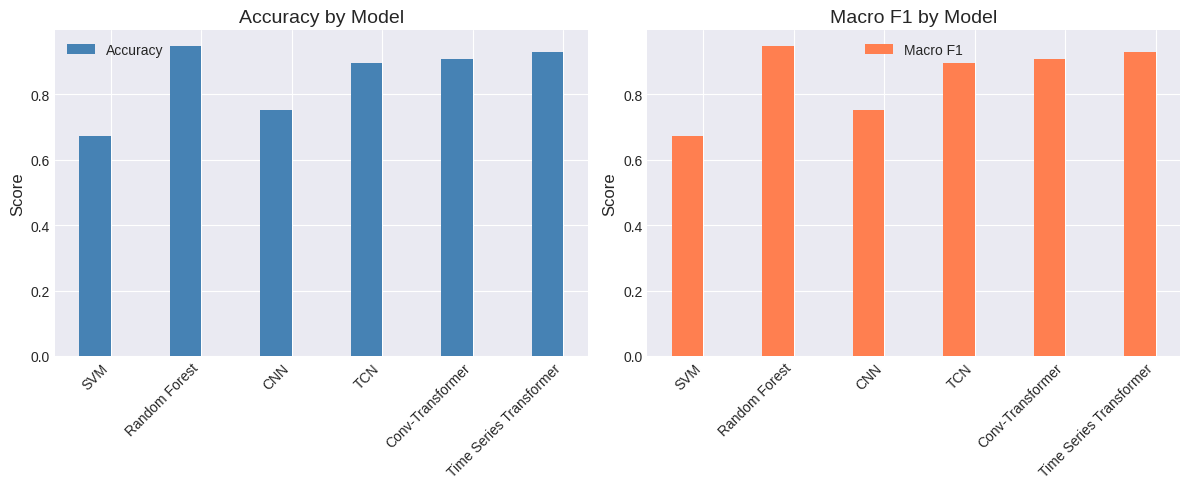

Summary figure saved to: results/model_comparison_summary_regenerated.png


In [111]:
import pandas as pd
import matplotlib.pyplot as plt

# Build summary DataFrame with Accuracy and Macro F1
summary_rows = [
    {"Model": name, "Accuracy": model_accuracies[name], "Macro F1": model_macro_f1[name]}
    for name in model_accuracies
]
summary_df = pd.DataFrame(summary_rows)

print("Model Summary (Accuracy & Macro F1):")
display(summary_df)

# Best model by accuracy and by macro F1
best_by_acc = summary_df.loc[summary_df["Accuracy"].idxmax(), "Model"]
best_by_f1 = summary_df.loc[summary_df["Macro F1"].idxmax(), "Model"]
print(f"\nBest model by Accuracy: {best_by_acc}")
print(f"Best model by Macro F1: {best_by_f1}")

plt.style.use('seaborn-v0_8-darkgrid') # Set academic plotting style

# Bar chart: Accuracy and Macro F1 per model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(summary_df))
w = 0.35

axes[0].bar(x - w/2, summary_df["Accuracy"], width=w, label="Accuracy", color="steelblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary_df["Model"], rotation=45, ha="right", fontsize=10)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].set_title("Accuracy by Model", fontsize=14)
axes[0].legend(fontsize=10)

axes[1].bar(x - w/2, summary_df["Macro F1"], width=w, label="Macro F1", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary_df["Model"], rotation=45, ha="right", fontsize=10)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title("Macro F1 by Model", fontsize=14)
axes[1].legend(fontsize=10)

plt.tight_layout()

# Save the summary figure to the results directory
fig_path_summary = RESULTS_DIR / "model_comparison_summary_regenerated.png"
fig.savefig(fig_path_summary, dpi=300, bbox_inches="tight")

plt.show()
print(f"Summary figure saved to: {fig_path_summary}")

### Feature Importance (Random Forest)

Let's examine which features (signal indices) the Random Forest model found most important for classification. This can provide insight into the patterns the model is utilizing.

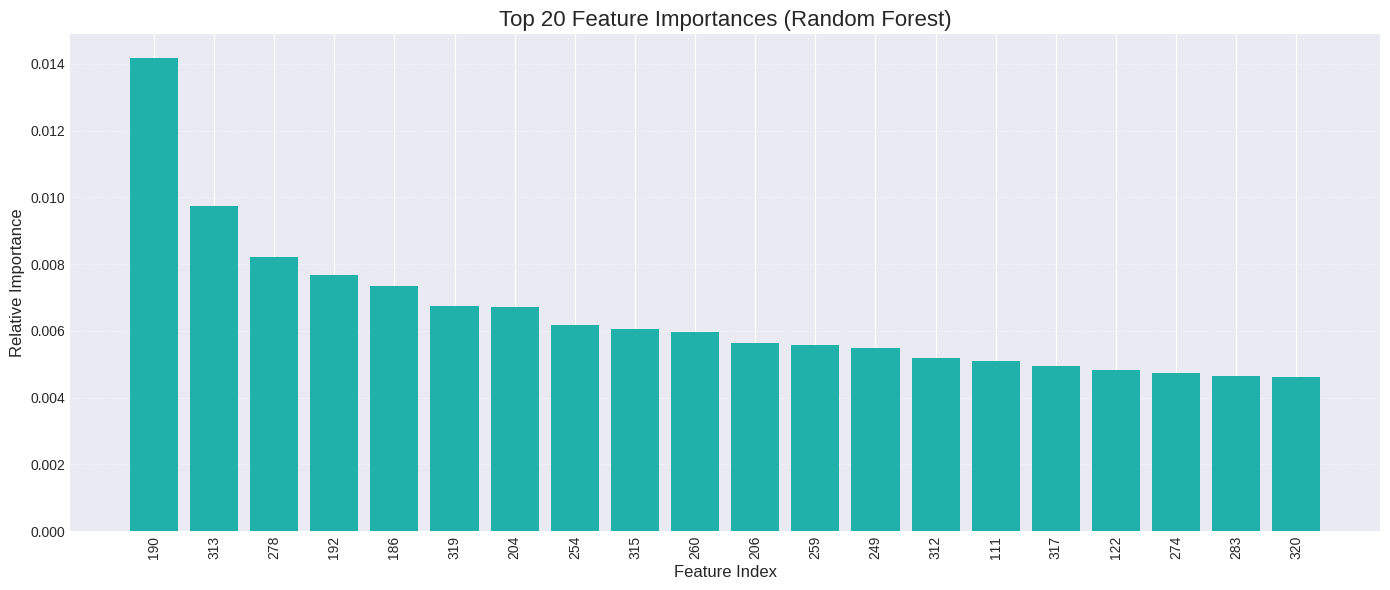

Feature importance plot saved to: results/random_forest_feature_importance.png


In [112]:
# Feature importance for Random Forest
if 'rf_clf' in locals() and hasattr(rf_clf, 'feature_importances_'):
    importances = rf_clf.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(14, 6))
    plt.title("Top 20 Feature Importances (Random Forest)", fontsize=16)
    plt.bar(range(20), importances[indices[:20]], color="lightseagreen", align="center")
    plt.xticks(range(20), indices[:20], rotation=90)
    plt.xlabel("Feature Index", fontsize=12)
    plt.ylabel("Relative Importance", fontsize=12)
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    fig_path = RESULTS_DIR / "random_forest_feature_importance.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Feature importance plot saved to: {fig_path}")
else:
    print("Random Forest classifier not trained or does not have feature_importances_ attribute.")


### ROC Curves for All Models

ROC curves show the trade-off between True Positive Rate and False Positive Rate. A larger Area Under the Curve (AUC) indicates a better model performance.

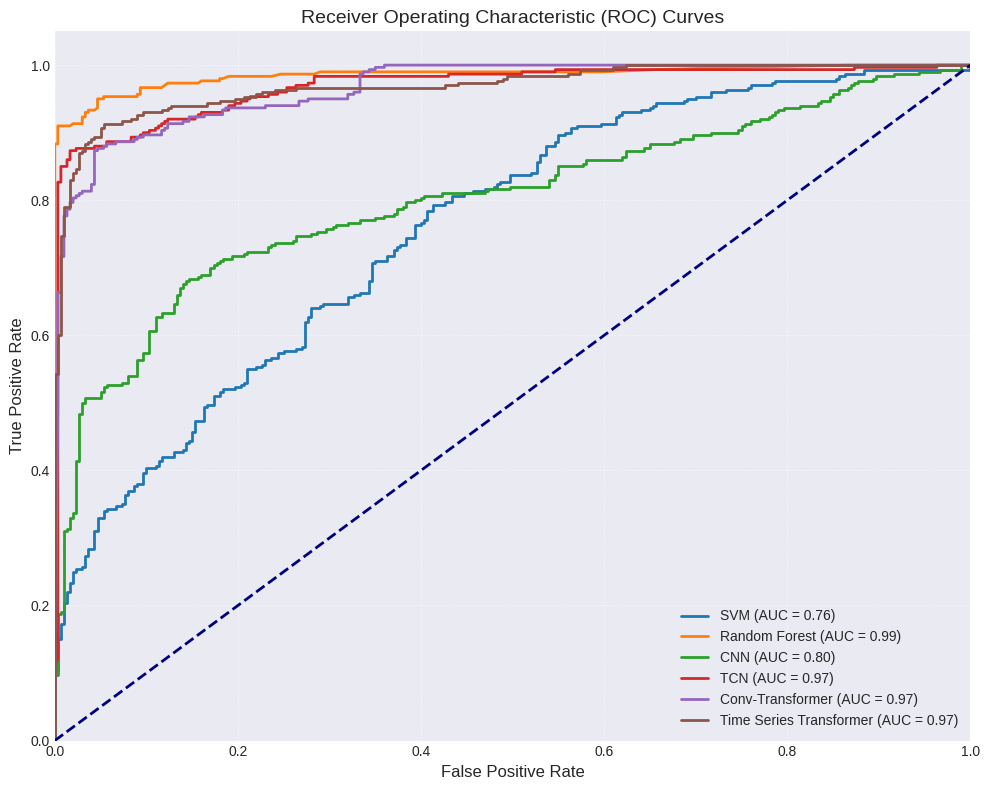

ROC curves plot saved to: results/model_roc_curves.png


In [113]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-darkgrid')

model_names = model_accuracies.keys()

for model_name in model_names:
    y_true = y_test
    y_pred_proba = None

    # Get probability predictions or decision function for ROC/PR curves
    if model_name == "SVM":
        # SGDClassifier with 'hinge' loss doesn't directly output probabilities.
        # Use decision_function as a proxy for score, then normalize/calibrate if needed for true proba.
        # For ROC curve calculation, decision_function scores are typically sufficient.
        y_score = svm_clf.decision_function(X_test_scaled)
        # Scale scores to be between 0 and 1 for consistency, if desired for display, though roc_curve handles raw scores
        # For proper proba, CalibratedClassifierCV is needed, but decision_function is fine for ROC/PR curves.
    elif model_name == "Random Forest":
        y_score = rf_clf.predict_proba(X_test_scaled)[:, 1]
    elif model_name == "CNN":
        y_score = cnn_model.predict(X_test_cnn, verbose=0).flatten()
    elif model_name == "TCN":
        y_score = tcn_model.predict(X_test_tcn, verbose=0).flatten()
    elif model_name == "Conv-Transformer":
        y_score = conv_transformer_model.predict(X_test_hybrid, verbose=0).flatten()
    elif model_name == "Time Series Transformer":
        y_score = ts_transformer_model.predict(X_test_ts, verbose=0).flatten()
    else:
        continue

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
fig_path_roc = RESULTS_DIR / "model_roc_curves.png"
plt.savefig(fig_path_roc, dpi=300, bbox_inches="tight")
plt.show()
print(f"ROC curves plot saved to: {fig_path_roc}")


### Precision-Recall Curves for All Models

Precision-Recall curves are useful, especially for imbalanced datasets, to understand the trade-off between precision and recall.

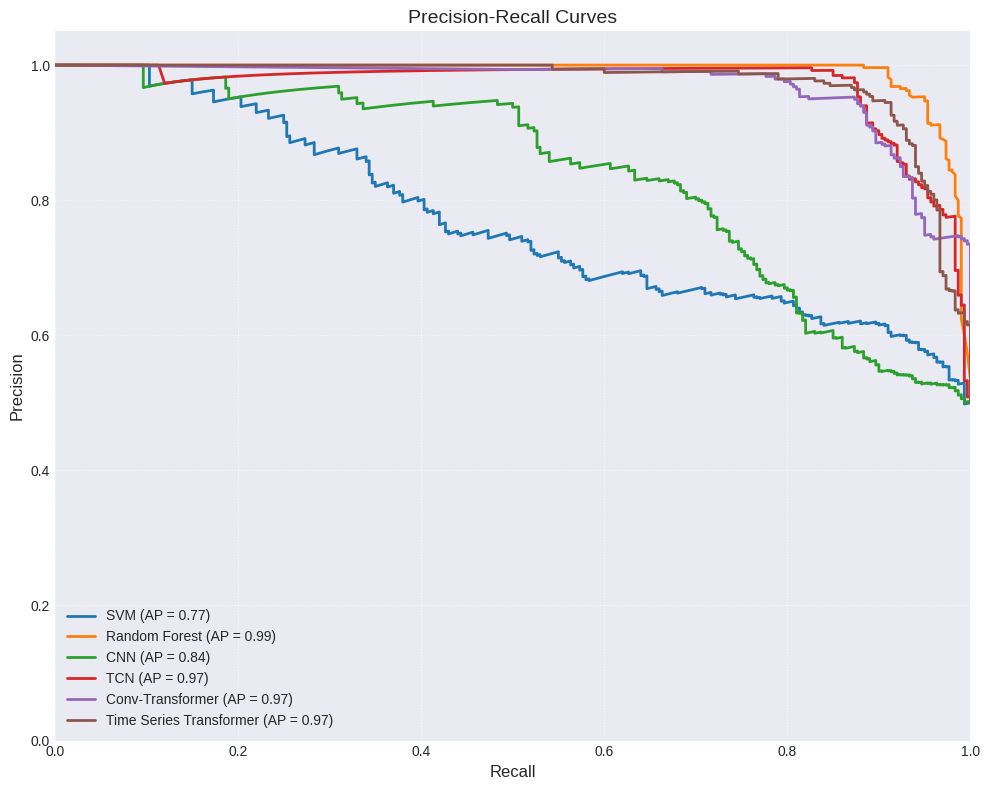

Precision-Recall curves plot saved to: results/model_precision_recall_curves.png


In [114]:
plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-darkgrid')

for model_name in model_names:
    y_true = y_test
    y_score = None

    if model_name == "SVM":
        y_score = svm_clf.decision_function(X_test_scaled)
    elif model_name == "Random Forest":
        y_score = rf_clf.predict_proba(X_test_scaled)[:, 1]
    elif model_name == "CNN":
        y_score = cnn_model.predict(X_test_cnn, verbose=0).flatten()
    elif model_name == "TCN":
        y_score = tcn_model.predict(X_test_tcn, verbose=0).flatten()
    elif model_name == "Conv-Transformer":
        y_score = conv_transformer_model.predict(X_test_hybrid, verbose=0).flatten()
    elif model_name == "Time Series Transformer":
        y_score = ts_transformer_model.predict(X_test_ts, verbose=0).flatten()
    else:
        continue

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    avg_precision = average_precision_score(y_true, y_score)
    plt.plot(recall, precision, lw=2, label=f'{model_name} (AP = {avg_precision:.2f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14)
plt.legend(loc="lower left", fontsize=10)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
fig_path_pr = RESULTS_DIR / "model_precision_recall_curves.png"
plt.savefig(fig_path_pr, dpi=300, bbox_inches="tight")
plt.show()
print(f"Precision-Recall curves plot saved to: {fig_path_pr}")
